In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
from matplotlib.ticker import ScalarFormatter

#2.1
print("2.1 Datenfeld für Vorhersage")
print("Die Vorhersagen werden für das Daten-Feld 'fatalities' getroffen.")

try:
    df = pd.read_csv('aviation-accident.csv', sep=';', encoding='latin1')
except:
    df = pd.read_csv('aviation-accident.csv', sep=';', encoding='cp1252')

df['fatalities'] = pd.to_numeric(df['fatalities'], errors='coerce').fillna(0)
df['year'] = pd.to_numeric(df['year'], errors='coerce').fillna(df['year'].median())

2.1 Datenfeld für Vorhersage
Die Vorhersagen werden für das Daten-Feld 'fatalities' getroffen.


In [6]:
#2.2
print("2.2 Statistische Informationen")
for col in df.columns:
    print(f"--- Feld: {col} ---")
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"Mittelwert: {df[col].mean():.2f} | Median: {df[col].median():.2f} | Std-Abw: {df[col].std():.2f}")
    else:
        print(f"Typ: Kategorial | Einzigartige Werte: {df[col].nunique()} | Modus: {df[col].mode()[0]}")
    print("-" * 40)

2.2 Statistische Informationen
--- Feld: date ---
Typ: Kategorial | Einzigartige Werte: 15055 | Modus: 10-MAY-1940
----------------------------------------
--- Feld: type ---
Typ: Kategorial | Einzigartige Werte: 3189 | Modus: Douglas C-47A (DC-3)
----------------------------------------
--- Feld: registration ---
Typ: Kategorial | Einzigartige Werte: 21854 | Modus: LZ-...
----------------------------------------
--- Feld: operator ---
Typ: Kategorial | Einzigartige Werte: 5984 | Modus: USAAF
----------------------------------------
--- Feld: fatalities ---
Mittelwert: 5.06 | Median: 0.00 | Std-Abw: 17.13
----------------------------------------
--- Feld: location ---
Typ: Kategorial | Einzigartige Werte: 14564 | Modus: unknown
----------------------------------------
--- Feld: country ---
Typ: Kategorial | Einzigartige Werte: 232 | Modus: USA
----------------------------------------
--- Feld: cat ---
Typ: Kategorial | Einzigartige Werte: 11 | Modus: A1
--------------------------------

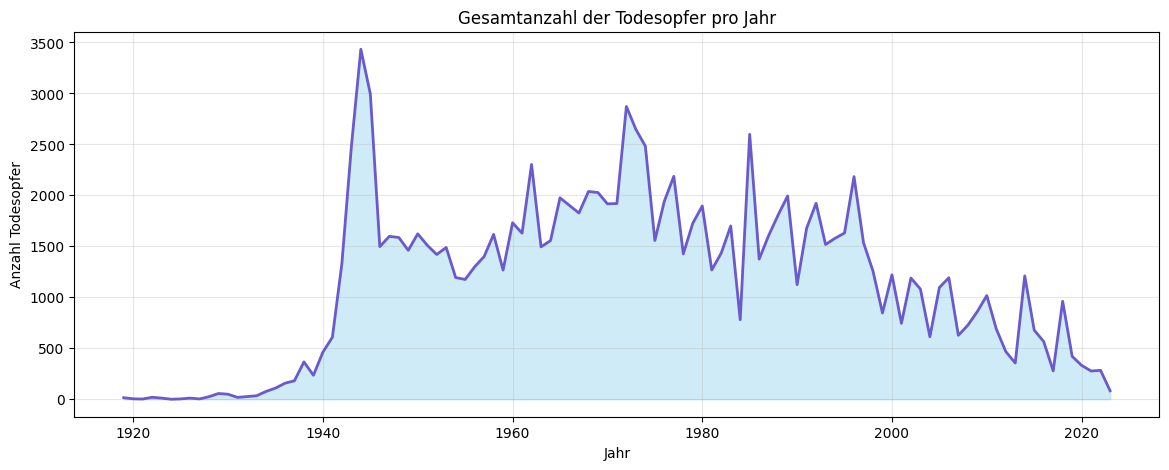

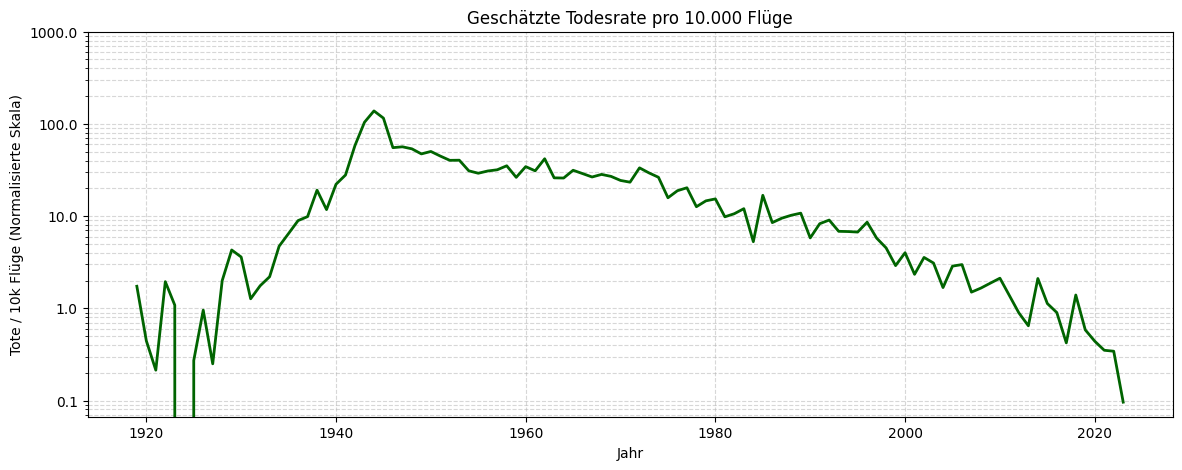

In [7]:
#2.3

yearly_fats = df.groupby('year')['fatalities'].sum().reset_index()

#Grafik 1
plt.figure(figsize=(14, 5))
plt.fill_between(yearly_fats['year'], yearly_fats['fatalities'], color="skyblue", alpha=0.4)
plt.plot(yearly_fats['year'], yearly_fats['fatalities'], color="Slateblue", linewidth=2)
plt.title('Gesamtanzahl der Todesopfer pro Jahr')
plt.xlabel('Jahr')
plt.ylabel('Anzahl Todesopfer')
plt.grid(True, alpha=0.3)
plt.show()

#Grafik 2
yearly_fats['est_flights_10k'] = (np.exp((yearly_fats['year'] - 1920) / 22) * 8) + 1
yearly_fats['rate_per_10k'] = yearly_fats['fatalities'] / yearly_fats['est_flights_10k']

plt.figure(figsize=(14, 5))
ax = sns.lineplot(x='year', y='rate_per_10k', data=yearly_fats, color='darkgreen', linewidth=2)


plt.yscale('log')

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([0.1, 1, 10, 100, 1000])

plt.title('Geschätzte Todesrate pro 10.000 Flüge')
plt.ylabel('Tote / 10k Flüge (Normalisierte Skala)')
plt.xlabel('Jahr')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [8]:
#2.4
scaler = StandardScaler()
df['year_scaled'] = scaler.fit_transform(df[['year']])

print("2.4 Skalierung des Jahres")
print("Vorschau ausgewählter Jahre (Original vs. Skaliert):")

selected_years = [1919, 1950, 1975, 2000, 2023]
preview = df[df['year'].isin(selected_years)].drop_duplicates(subset=['year']).sort_values('year')

print(preview[['year', 'year_scaled']].to_string(index=False))

2.4 Skalierung des Jahres
Vorschau ausgewählter Jahre (Original vs. Skaliert):
 year  year_scaled
 1919    -2.160166
 1950    -0.936493
 1975     0.050339
 2000     1.037172
 2023     1.945058
